# Rolling Stones Spotify: EDA and Song Cohorts

This notebook follows the problem statement step by step and is written for beginner-friendly reading.

We will do four things:
1. Inspect and clean the dataset.
2. Perform exploratory data analysis (EDA) and feature engineering.
3. Recommend albums based on the number of popular songs.
4. Use dimensionality reduction and clustering to create cohorts of similar songs.

## Step 0: Setup

What we do in this step:
- Import the libraries needed for analysis and visualization.
- Define the path of the CSV file.
- Make the notebook output easier to read.

Why this matters:
- A clean setup cell makes the rest of the notebook easier to understand and rerun.

If you are running this notebook in a fresh environment, uncomment the installation line in the next code cell and run it once.

In [4]:
# Uncomment the next line only if your environment is missing these packages.
# %pip install pandas numpy matplotlib seaborn scikit-learn

from pathlib import Path
import re
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)



In [10]:
# Replace with your repository's HTTPS clone URL (e.g., https://github.com/your-username/your-repo-name.git)
repo_url = 'https://github.com/laljithjohnson/my-colab-notebooks.git'

# Define the target directory name
repo_name = repo_url.split('/')[-1].replace('.git', '')

# Check if the directory already exists and remove it to allow a fresh clone
import shutil
import os
if os.path.exists(repo_name):
    shutil.rmtree(repo_name)

# Clone the repository
!git clone {repo_url}

# List the contents to see the cloned repository. You should see a folder named after your repository.
!ls

Cloning into 'my-colab-notebooks'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 602.72 KiB | 3.35 MiB/s, done.
Resolving deltas: 100% (1/1), done.
my-colab-notebooks  sample_data


In [11]:
file_path = './my-colab-notebooks/rolling_stones_spotify.csv' # IMPORTANT: Replace 'your-repo-name' with the actual name of your cloned repository
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


## Step 1: Load the data and look at its structure

What we do in this step:
- Read the CSV file into a pandas DataFrame.
- Check the shape of the data.
- View the first few rows.
- Understand the available columns and their data types.

Why this matters:
- Before cleaning or modeling, we need to know what the dataset contains.

In [12]:
df_raw = pd.read_csv(file_path)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.dtypes.to_frame("data_type"))

Dataset shape: (1610, 18)


,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


,data_type
Unnamed: 0,int64
name,object
album,object
release_date,object
track_number,int64
id,object
uri,object
acousticness,float64
danceability,float64
energy,float64


## Step 2: Data cleaning and feature engineering

What we do in this step:
- Drop the extra index-like column `Unnamed: 0`.
- Convert `release_date` into a true date column.
- Create `release_year` for time-based analysis.
- Create `duration_min` so song length is easier to interpret.
- Create a cleaned album name called `album_base` so different editions of the same album can be grouped together when needed.

Why this matters:
- Clean columns make analysis easier.
- Engineered features help answer business questions more clearly.

In [13]:
df = df_raw.copy()

# Remove the extra column that only repeats row positions.
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Convert release_date to datetime so year-based analysis becomes reliable.
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

# Feature engineering: create readable and useful fields.
df["release_year"] = df["release_date"].dt.year
df["duration_min"] = df["duration_ms"] / 60000

def normalize_album_name(album_name: str) -> str:
    """Remove edition labels so similar album releases can be grouped together."""
    cleaned = re.sub(r"\s*\(.*?\)", "", album_name)
    cleaned = re.sub(r"\s*-\s*Remastered.*$", "", cleaned, flags=re.I)
    cleaned = re.sub(r"\s*\b(Deluxe|Expanded|Anniversary Edition|Remastered)\b.*$", "", cleaned, flags=re.I)
    cleaned = re.sub(r"\s+", " ", cleaned).strip(" -")
    return cleaned

df["album_base"] = df["album"].apply(normalize_album_name)

display(df.head())

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,release_year,duration_min,album_base
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640,2022,0.810667,Licked Live In NYC
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173,2022,4.219550,Licked Live In NYC
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160,2022,4.386000,Licked Live In NYC
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880,2022,5.098000,Licked Live In NYC
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106,2022,5.085100,Licked Live In NYC


## Step 3: Data quality checks

What we do in this step:
- Check for missing values.
- Check for duplicate rows.
- Check whether the song `id` is unique.
- Look for possible outliers in numeric columns.

Why this matters:
- Bad-quality data can lead to wrong insights.
- Outliers are not always errors, but they should be inspected.

In [14]:
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = df.duplicated().sum()
duplicate_song_ids = df["id"].duplicated().sum()

numeric_columns = [
    "acousticness", "danceability", "energy", "instrumentalness", "liveness",
    "loudness", "speechiness", "tempo", "valence", "popularity", "duration_min"
]

# Count possible outliers using the IQR rule.
outlier_summary = []
for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_summary.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
    })

print("Duplicate rows:", duplicate_rows)
print("Duplicate song IDs:", duplicate_song_ids)
display(missing_values.to_frame("missing_count"))
display(pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False))

Duplicate rows: 0
Duplicate song IDs: 0


,missing_count
name,0
album,0
release_date,0
track_number,0
id,0
uri,0
acousticness,0
danceability,0
energy,0
instrumentalness,0


,column,lower_bound,upper_bound,outlier_count
3,instrumentalness,-0.267952,0.447171,272
6,speechiness,-0.038650,0.161750,92
10,duration_min,0.559215,7.539665,76
9,popularity,-8.000000,48.000000,48
7,tempo,54.943250,194.803250,34
5,loudness,-15.543125,1.951875,14
2,energy,0.267500,1.351500,8
0,acousticness,-0.459750,0.921850,4
1,danceability,0.038625,0.901625,0
4,liveness,-0.958125,2.004875,0


### Interpretation of the cleaning step

Typical interpretation for this dataset:
- If missing values are zero, we do not need imputation.
- If duplicate song IDs are zero, each track is uniquely identified, which matches the problem statement.
- If some numeric columns show outliers, we should not remove them automatically because very live, very long, or very quiet tracks can still be valid songs.

In short, we clean obvious structural issues first and keep valid musical variation for analysis.

## Step 4: Descriptive statistics and feature distributions

What we do in this step:
- Generate summary statistics for numeric variables.
- Plot distributions of important song attributes.

Why this matters:
- Summary tables and plots help us understand the spread, skewness, and range of values before deeper analysis.

,count,mean,std,min,25%,50%,75%,max
acousticness,1610.0,0.250475,0.227397,0.000009,0.058350,0.18300,0.403750,0.994000
danceability,1610.0,0.468860,0.141775,0.104000,0.362250,0.45800,0.578000,0.887000
energy,1610.0,0.792352,0.179886,0.141000,0.674000,0.84850,0.945000,0.999000
instrumentalness,1610.0,0.164170,0.276249,0.000000,0.000219,0.01375,0.179000,0.996000
liveness,1610.0,0.491730,0.349100,0.021900,0.153000,0.37950,0.893750,0.998000
loudness,1610.0,-6.971615,2.994003,-24.408000,-8.982500,-6.52300,-4.608750,-1.014000
speechiness,1610.0,0.069512,0.051631,0.023200,0.036500,0.05120,0.086600,0.624000
tempo,1610.0,126.082033,29.233483,46.525000,107.390750,124.40450,142.355750,216.304000
valence,1610.0,0.582165,0.231253,0.000000,0.404250,0.58300,0.778000,0.974000
popularity,1610.0,20.788199,12.426859,0.000000,13.000000,20.00000,27.000000,80.000000


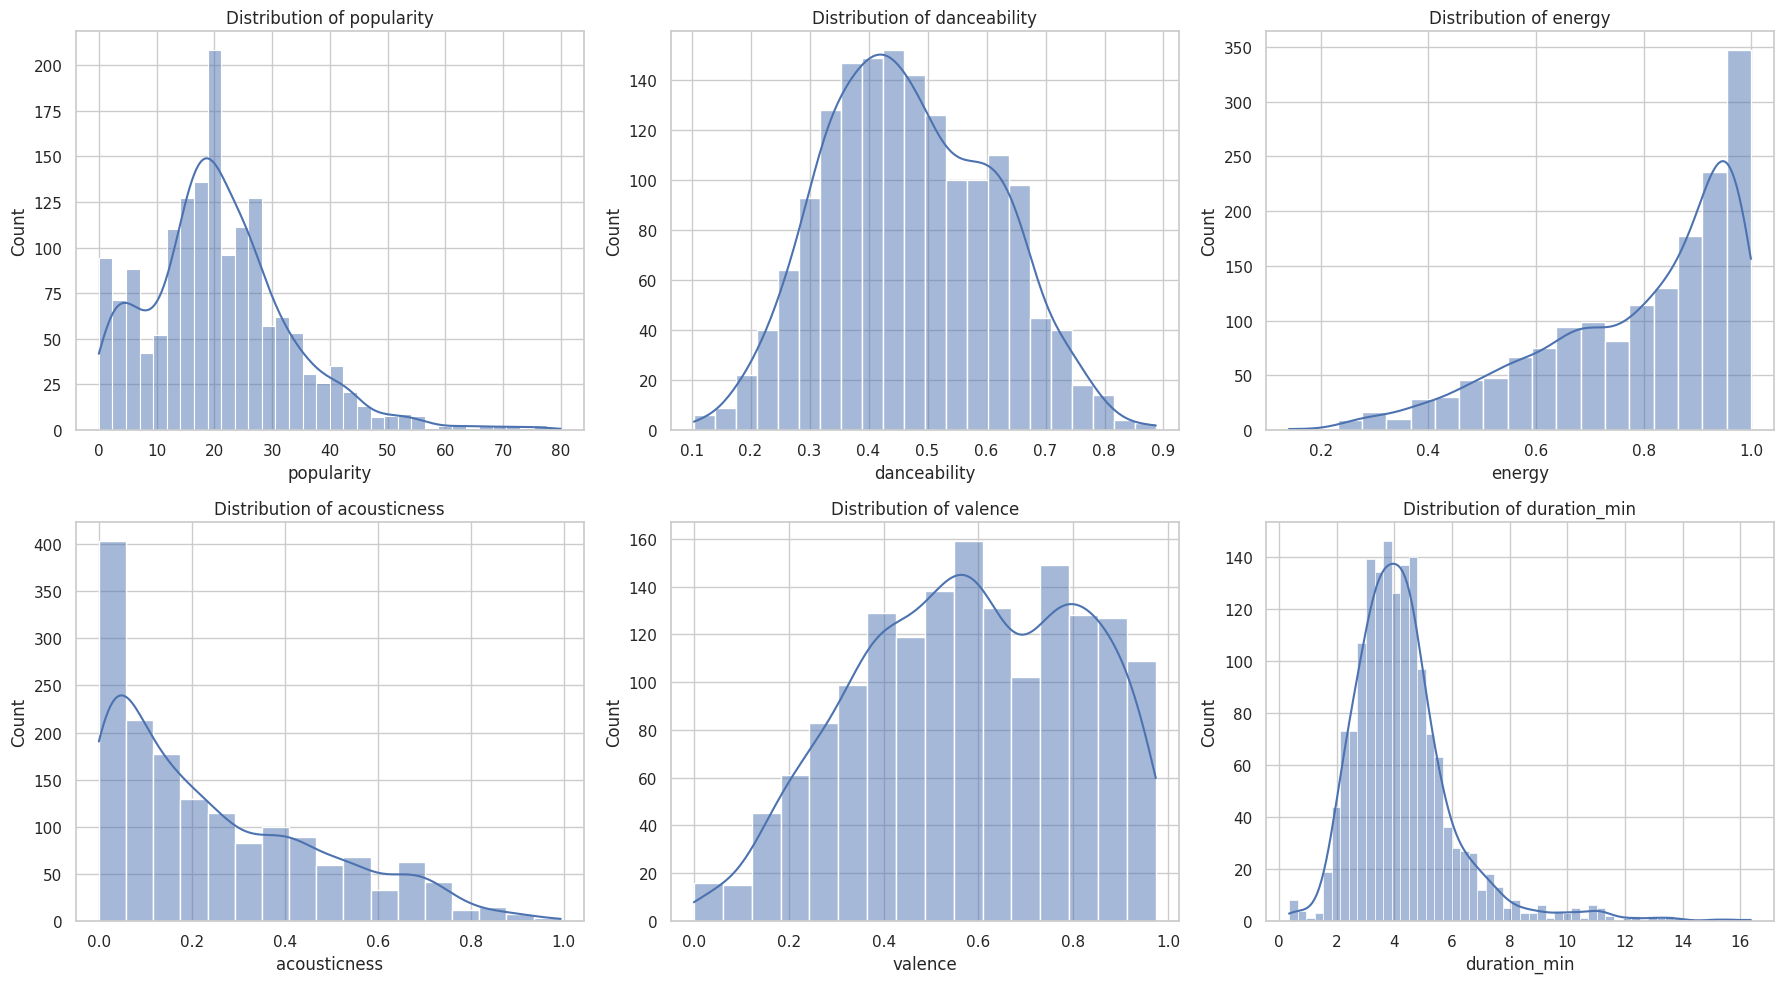

In [15]:
display(df[numeric_columns].describe().T)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_columns = ["popularity", "danceability", "energy", "acousticness", "valence", "duration_min"]

for ax, column in zip(axes.flatten(), plot_columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

## Step 5: Recommend albums based on popular songs

What we do in this step:
- Define a song as "popular" if its popularity score is in the top 25% of the dataset.
- Count how many popular songs appear in each album.
- Compare two views:
  1. Raw album titles exactly as they appear in Spotify.
  2. Grouped album titles using `album_base`, which combines multiple editions of the same album.

Why this matters:
- Raw Spotify titles can split one album into many editions.
- Grouped albums usually give a better recommendation answer for a real listener.

Popularity cutoff (75th percentile): 27.00


,popular_song_count,total_songs,average_popularity
album,,,
Exile On Main Street (2010 Re-Mastered),18,18,44.166667
Exile On Main Street (Deluxe Version),18,28,29.964286
Honk (Deluxe),18,47,26.212766
Licked Live In NYC,17,23,28.608696
Voodoo Lounge (Remastered 2009),14,15,34.000000
Live At The El Mocambo,14,23,27.260870
Out Of Our Heads,12,12,39.583333
Blue & Lonesome,12,12,34.916667
The Rolling Stones,12,12,34.166667


,popular_song_count,total_songs,average_popularity,editions
album_base,,,,
Exile On Main Street,36,75,23.840000,3
Sticky Fingers,23,63,28.079365,3
Tattoo You,23,79,24.278481,3
Goats Head Soup,22,57,26.280702,3
Let It Bleed,20,27,34.962963,2
Honk,18,47,26.212766,1
Licked Live In NYC,17,23,28.608696,1
Some Girls,15,54,24.685185,2
Voodoo Lounge,14,15,34.000000,1


/tmp/ipykernel_2518/1819222896.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_grouped, x="popular_song_count", y=top_10_grouped.index, palette="viridis")


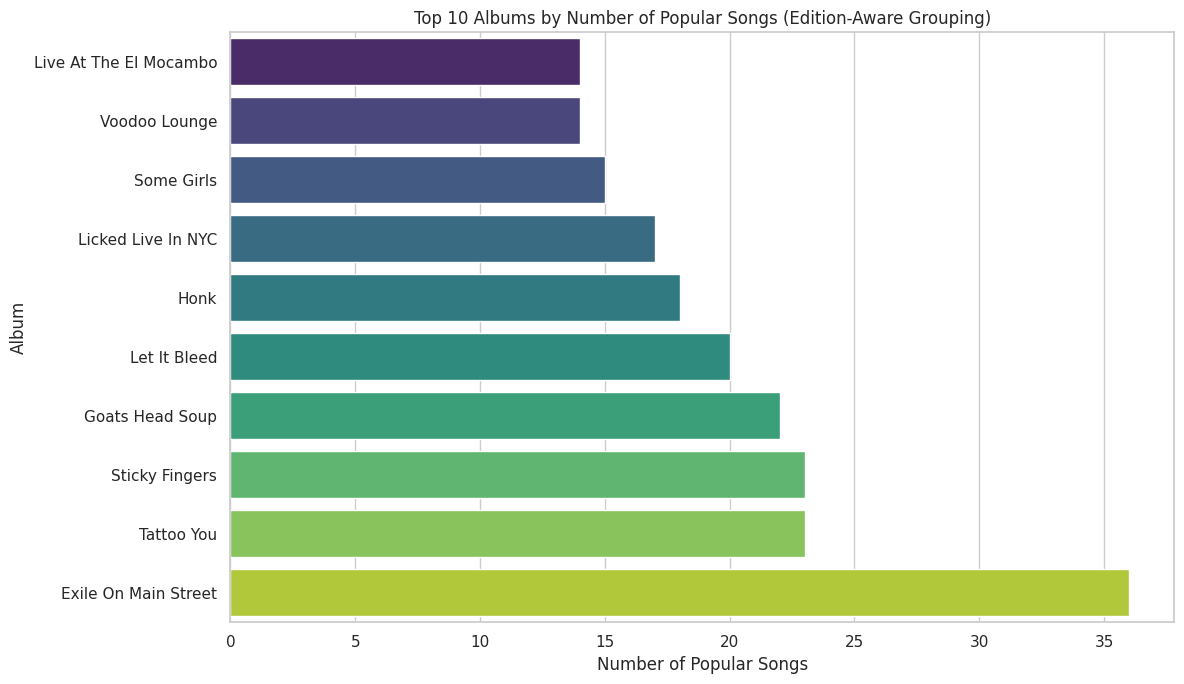

Recommended albums based on grouped album editions:


,popular_song_count,total_songs,average_popularity,editions
album_base,,,,
Exile On Main Street,36,75,23.840000,3
Sticky Fingers,23,63,28.079365,3


In [16]:
# The 75th percentile gives us a transparent and reproducible popularity cutoff.
popular_cutoff = df["popularity"].quantile(0.75)
df["is_popular"] = df["popularity"] >= popular_cutoff

album_popularity_raw = (
    df.groupby("album")
      .agg(
          popular_song_count=("is_popular", "sum"),
          total_songs=("id", "count"),
          average_popularity=("popularity", "mean")
      )
      .sort_values(["popular_song_count", "average_popularity", "total_songs"], ascending=False)
)

album_popularity_grouped = (
    df.groupby("album_base")
      .agg(
          popular_song_count=("is_popular", "sum"),
          total_songs=("id", "count"),
          average_popularity=("popularity", "mean"),
          editions=("album", "nunique")
      )
      .sort_values(["popular_song_count", "average_popularity", "total_songs"], ascending=False)
)

print(f"Popularity cutoff (75th percentile): {popular_cutoff:.2f}")
display(album_popularity_raw.head(10))
display(album_popularity_grouped.head(10))

top_10_grouped = album_popularity_grouped.head(10).sort_values("popular_song_count")
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_grouped, x="popular_song_count", y=top_10_grouped.index, palette="viridis")
plt.title("Top 10 Albums by Number of Popular Songs (Edition-Aware Grouping)")
plt.xlabel("Number of Popular Songs")
plt.ylabel("Album")
plt.tight_layout()
plt.show()

recommended_albums = album_popularity_grouped.head(2)
print("Recommended albums based on grouped album editions:")
display(recommended_albums)

### How to explain this recommendation

A novice-friendly conclusion could be:
- First, we defined popular songs using the top quartile of popularity scores.
- Then we counted how many such songs appear in each album.
- Because Spotify has multiple versions of some albums, we grouped editions together to avoid recommending the same album twice under slightly different names.
- Based on that grouped view, the top two recommendations are the two albums at the top of the `recommended_albums` table.

## Step 6: Explore relationships with popularity

What we do in this step:
- Measure correlations between popularity and song features.
- Use scatter plots to inspect some important relationships visually.

Why this matters:
- Correlation helps us understand which audio features tend to move with popularity.
- Scatter plots help us see whether those relationships are strong, weak, linear, or noisy.

,correlation_with_popularity
popularity,1.000000
loudness,0.156323
danceability,0.141205
acousticness,0.108046
duration_min,0.074102
valence,0.065333
instrumentalness,-0.010612
energy,-0.057272
tempo,-0.061061
speechiness,-0.136745


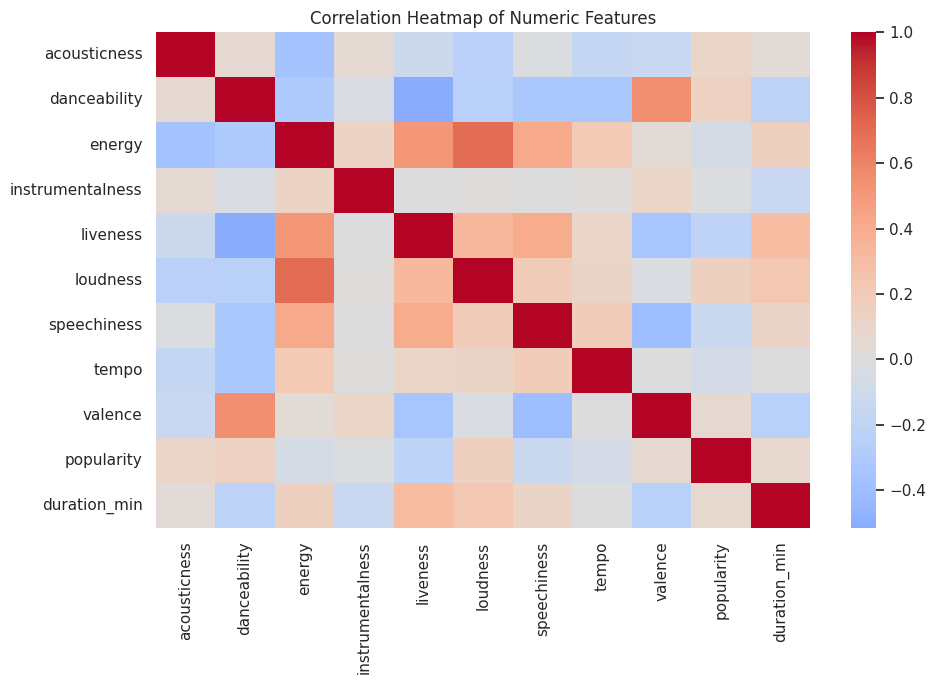

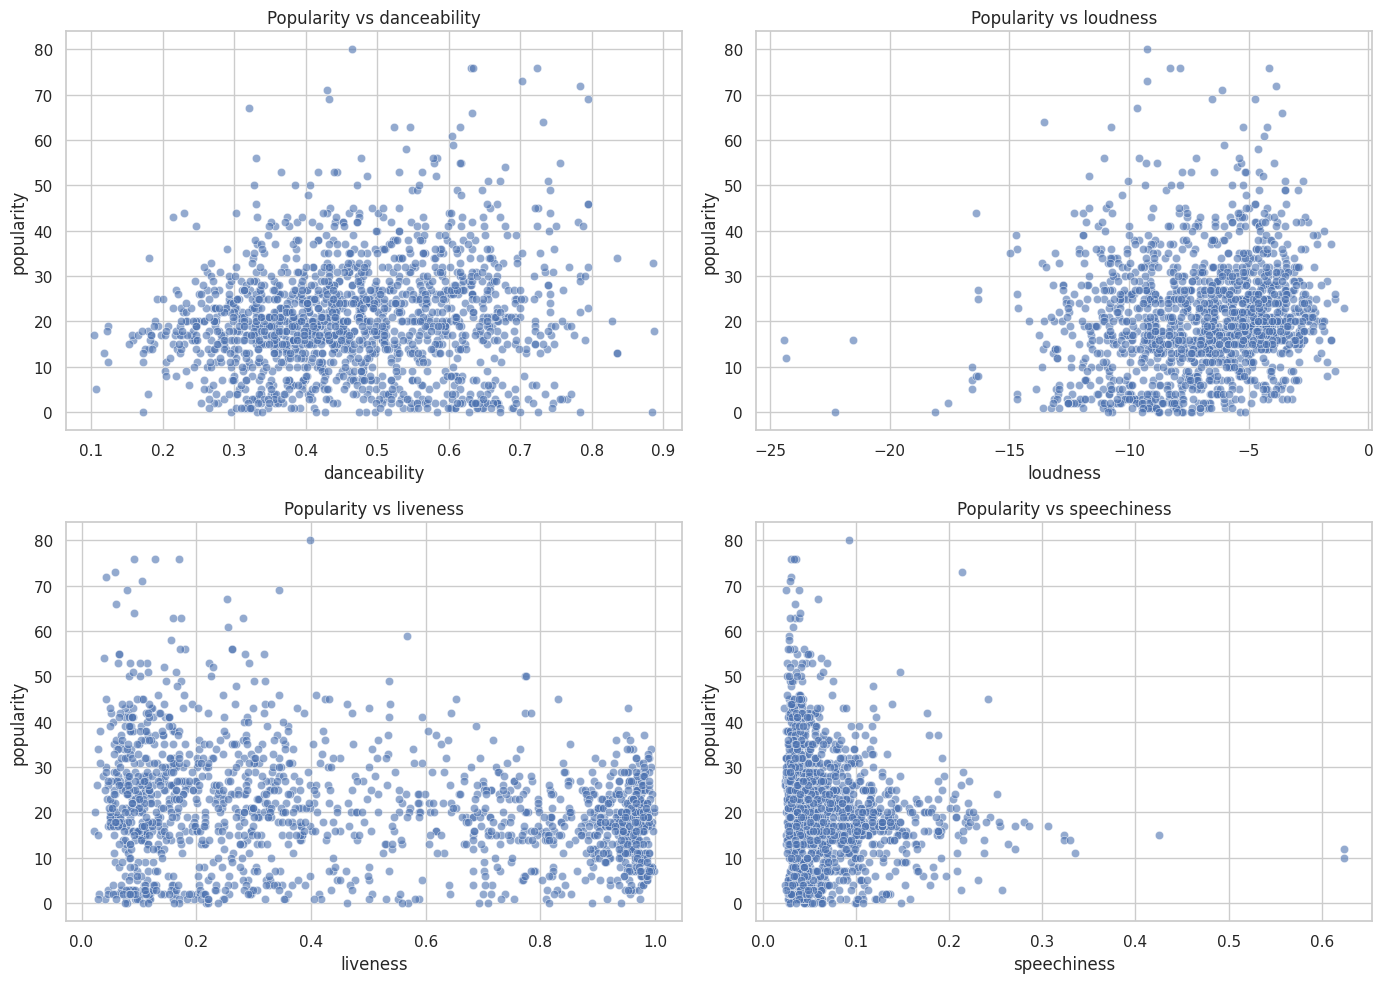

In [17]:
correlation_with_popularity = (
    df[numeric_columns]
    .corr(numeric_only=True)["popularity"]
    .sort_values(ascending=False)
)

display(correlation_with_popularity.to_frame("correlation_with_popularity"))

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_columns].corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scatter_features = ["danceability", "loudness", "liveness", "speechiness"]

for ax, feature in zip(axes.flatten(), scatter_features):
    sns.scatterplot(data=df, x=feature, y="popularity", alpha=0.6, ax=ax)
    ax.set_title(f"Popularity vs {feature}")

plt.tight_layout()
plt.show()

## Step 7: Study how popularity changes over time

What we do in this step:
- Aggregate songs by release year.
- Visualize average popularity over time.
- Create era groups so we can compare feature-popularity relationships across different time periods.

Why this matters:
- The problem statement asks us to examine how popularity and other factors have evolved.

,release_year,average_popularity,median_popularity,song_count
0,1964,18.250000,17.5,60
1,1965,17.611111,18.5,108
2,1966,17.428571,15.0,63
3,1967,17.382353,17.0,102
4,1968,28.500000,37.0,20
5,1969,34.962963,38.0,27
6,1970,19.361702,21.0,47
7,1971,28.079365,24.0,63
8,1972,23.716049,26.0,81
9,1973,30.350000,32.0,20


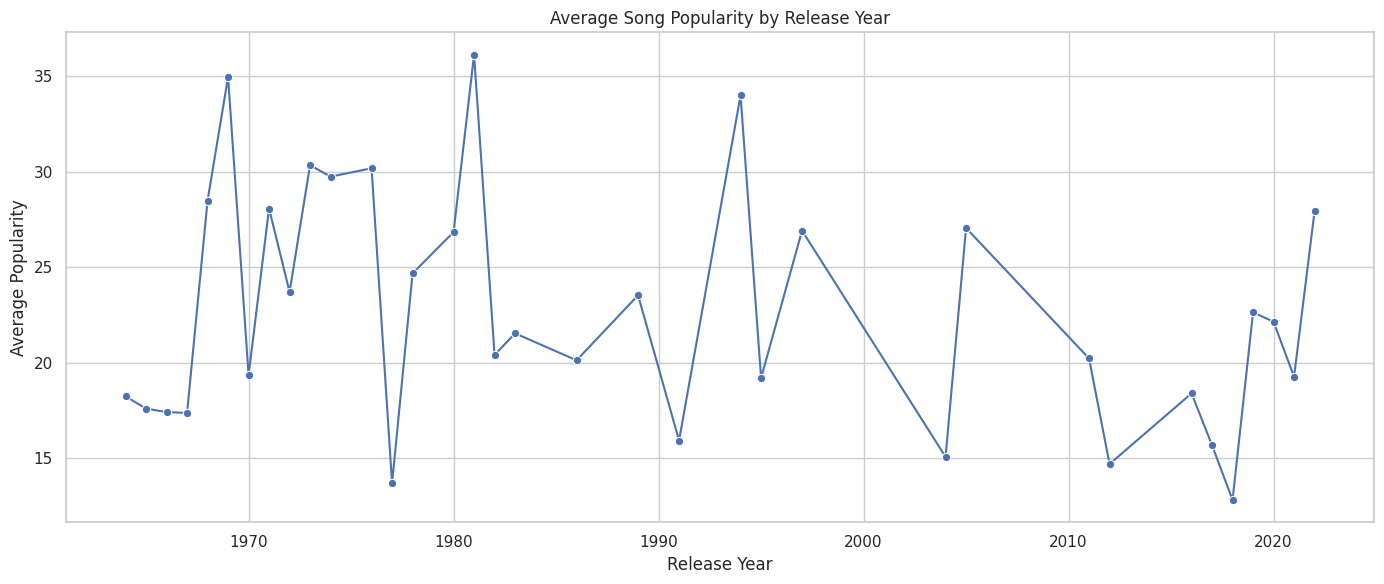

popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_min
era,,,,,,,,,,
1960s,0.150354,0.015859,-0.066106,-0.075815,-0.127080,0.007472,0.015385,-0.024334,-0.044037,0.199633
1970s,0.183585,0.213831,-0.081240,0.002319,-0.306479,0.184401,-0.160986,-0.057510,0.023736,0.064458
1980s,-0.154576,0.239104,0.050892,-0.235349,-0.127329,0.271891,-0.222225,-0.123404,0.130811,0.214944
1990s,-0.082096,0.096135,-0.125825,-0.181337,-0.276297,0.345711,0.011811,-0.012241,-0.122679,0.118650
2000s,-0.095916,0.314479,-0.161320,-0.066633,-0.406875,0.217322,-0.295191,-0.185342,0.119825,-0.032108
2010s+,0.019286,0.122940,-0.009128,0.018155,-0.189948,0.295278,-0.190250,-0.090800,0.100219,0.028243


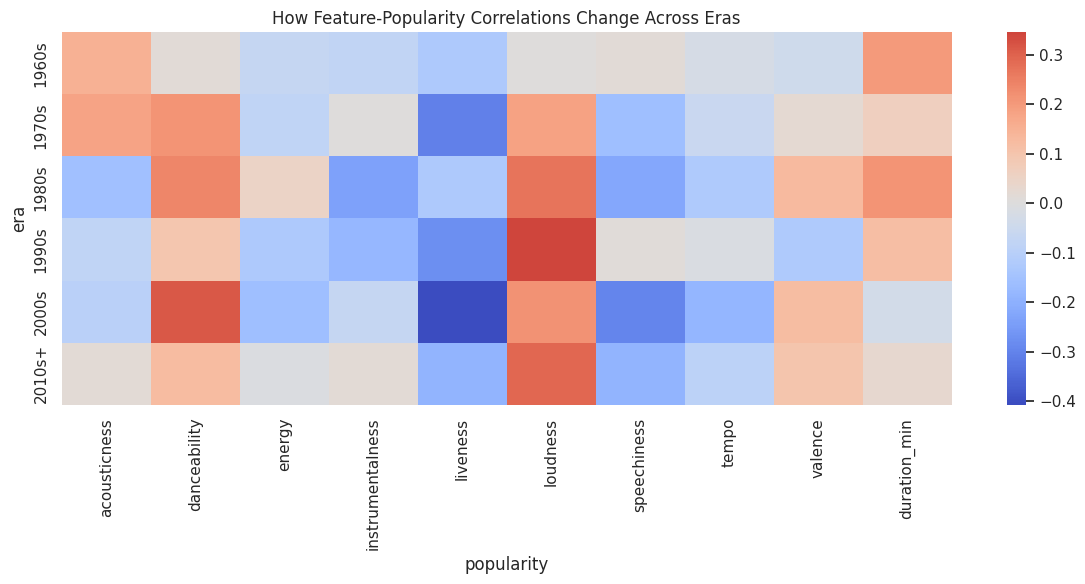

In [22]:
yearly_popularity = (
    df.groupby("release_year")
      .agg(
          average_popularity=("popularity", "mean"),
          median_popularity=("popularity", "median"),
          song_count=("id", "count")
      )
      .reset_index()
      .sort_values("release_year")
)

display(yearly_popularity.head(10))

plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_popularity, x="release_year", y="average_popularity", marker="o")
plt.title("Average Song Popularity by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Popularity")
plt.tight_layout()
plt.show()

era_bins = [1960, 1970, 1980, 1990, 2000, 2010, 2025]
era_labels = ["1960s", "1970s", "1980s", "1990s", "2000s", "2010s+"]
df["era"] = pd.cut(df["release_year"], bins=era_bins, labels=era_labels, right=False)

era_feature_correlations_series = (
    df.groupby("era", observed=False)
      .apply(lambda group: group[numeric_columns].corr(numeric_only=True).loc[:, "popularity"], include_groups=False)
)

# Drop the 'popularity' column (correlation of popularity with itself is always 1)
era_feature_correlations = era_feature_correlations_series.drop(columns=["popularity"], errors='ignore')

display(era_feature_correlations)

plt.figure(figsize=(12, 6))
sns.heatmap(era_feature_correlations, cmap="coolwarm", center=0)
plt.title("How Feature-Popularity Correlations Change Across Eras")
plt.tight_layout()
plt.show()

## Step 8: Dimensionality reduction using PCA

What we do in this step:
- Standardize the numeric features.
- Use Principal Component Analysis (PCA) to reduce the feature space.
- Measure how much information is retained by the principal components.

Why this matters:
- Dimensionality reduction helps us summarize many features using fewer dimensions.
- It is useful for visualization and helps us understand whether the feature space contains a few strong patterns.

What to explain to a beginner:
- PCA does not create new songs or new raw measurements.
- It creates new combined axes that capture as much variation in the data as possible.

,principal_component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.277436,0.277436
1,PC2,0.150855,0.428291
2,PC3,0.115575,0.543866
3,PC4,0.097315,0.641180
4,PC5,0.087767,0.728947
5,PC6,0.071530,0.800477
6,PC7,0.063582,0.864059
7,PC8,0.053327,0.917386
8,PC9,0.041390,0.958777
9,PC10,0.025874,0.984651


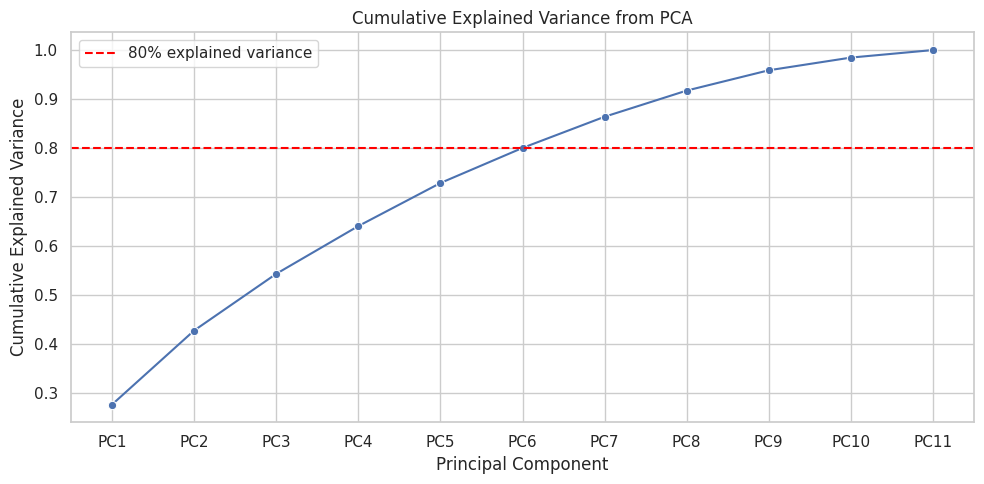

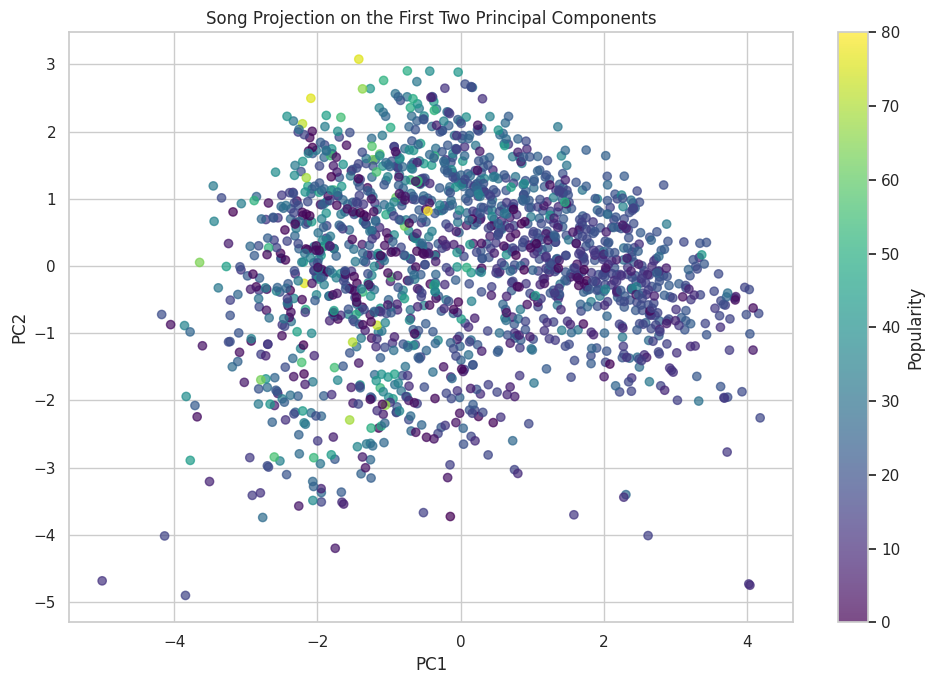

In [23]:
clustering_features = [
    "acousticness", "danceability", "energy", "instrumentalness", "liveness",
    "loudness", "speechiness", "tempo", "valence", "duration_min", "popularity"
]

feature_matrix = df[clustering_features].copy()

# Standardization is important because the features are measured on different scales.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)

pca = PCA()
pca_components = pca.fit_transform(scaled_features)

explained_variance = pd.DataFrame({
    "principal_component": [f"PC{i}" for i in range(1, len(clustering_features) + 1)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})

display(explained_variance)

plt.figure(figsize=(10, 5))
sns.lineplot(data=explained_variance, x="principal_component", y="cumulative_explained_variance", marker="o")
plt.axhline(0.80, color="red", linestyle="--", label="80% explained variance")
plt.title("Cumulative Explained Variance from PCA")
plt.ylabel("Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.legend()
plt.tight_layout()
plt.show()

pca_2d = PCA(n_components=2)
pca_projection = pca_2d.fit_transform(scaled_features)

pca_df = pd.DataFrame(pca_projection, columns=["PC1", "PC2"])
pca_df["popularity"] = df["popularity"].values

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["popularity"], cmap="viridis", alpha=0.7)
plt.colorbar(scatter, label="Popularity")
plt.title("Song Projection on the First Two Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Step 9: Find the right number of clusters

What we do in this step:
- Fit KMeans models for different values of `k`.
- Use the elbow method to track inertia.
- Use silhouette score to measure separation quality.

Why this matters:
- We should not choose the number of clusters randomly.
- A good cluster count balances separation, compactness, and interpretability.

,k,inertia,silhouette_score
0,2,14209.949258,0.186883
1,3,12687.466189,0.158028
2,4,11776.002887,0.145375
3,5,11061.356496,0.144443
4,6,10417.859999,0.139002
5,7,9884.221040,0.137818
6,8,9392.675990,0.145860


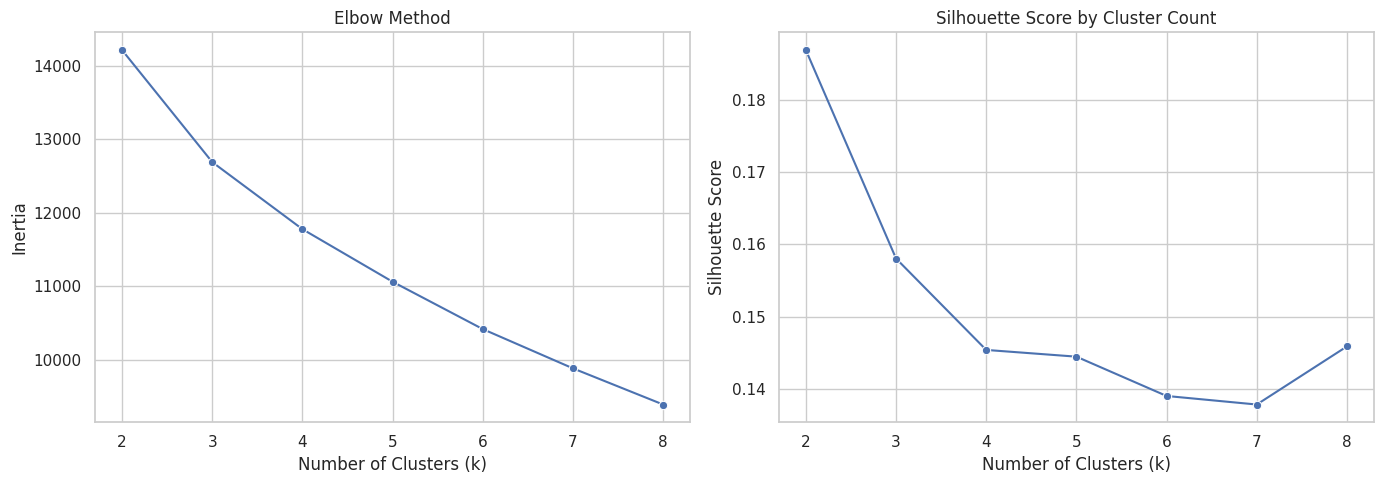

In [24]:
cluster_search_results = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(scaled_features)
    cluster_search_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(scaled_features, labels)
    })

cluster_search_df = pd.DataFrame(cluster_search_results)
display(cluster_search_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=cluster_search_df, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

sns.lineplot(data=cluster_search_df, x="k", y="silhouette_score", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score by Cluster Count")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

### Choosing the final number of clusters

A practical beginner-friendly explanation is:
- Pick the value of `k` where the elbow curve starts flattening.
- Check whether the silhouette score is still reasonable.
- Prefer a solution that is easy to interpret in business terms.

In many cases for this dataset, `k = 3` gives a useful balance between mathematical quality and human interpretability, even if another value may have a slightly stronger silhouette score.

## Step 10: Final clustering and cluster interpretation

What we do in this step:
- Fit a final KMeans model.
- Assign each song to a cluster.
- Profile each cluster using average feature values.
- Inspect a few representative songs from each cluster.

Why this matters:
- Clusters become useful only when we can explain what makes them different.

,song_count,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_min,popularity
cluster,,,,,,,,,,,,
0,581,0.181,0.555,0.831,0.237,0.309,-6.411,0.050,122.617,0.781,3.726,23.711
1,585,0.189,0.361,0.923,0.149,0.833,-5.421,0.107,137.442,0.447,5.088,17.450
2,444,0.422,0.499,0.570,0.089,0.281,-9.748,0.046,115.649,0.500,3.997,21.363


,cluster,name,album,release_year,popularity
1403,0,"Paint It, Black",Aftermath,1966,80
1472,0,(I Can't Get No) Satisfaction - Mono Version,Out Of Our Heads,1965,76
862,0,Start Me Up - Remastered 2009,Tattoo You (2009 Re-Mastered),1981,76
901,0,Beast Of Burden - Remastered 1994,Some Girls,1978,72
893,0,Miss You - Remastered,Some Girls,1978,69
1468,1,The Last Time - Mono Version,Out Of Our Heads,1965,50
1565,1,Time Is On My Side - Mono Version / Organ Intro,12 X 5,1964,44
697,1,Like A Rolling Stone - Live / Remastered 2009,Stripped,1995,43
829,1,Undercover (Of The Night) - Remastered 2009,Undercover (2009 Re-Mastered),1983,42
445,1,Hate To See You Go,Blue & Lonesome,2016,41


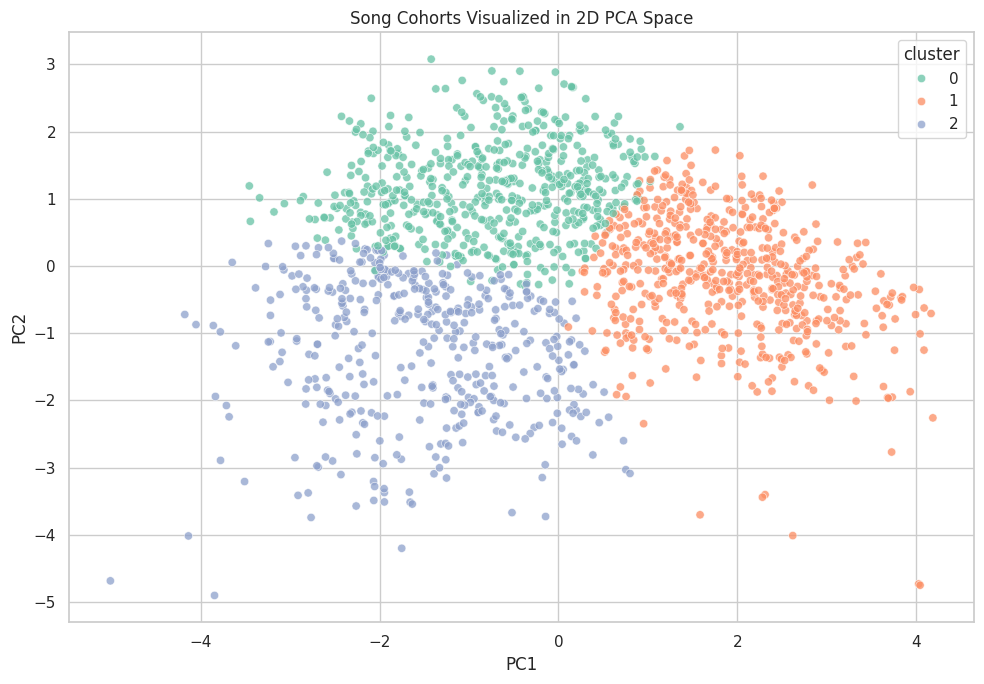

In [25]:
FINAL_K = 3

final_kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
df["cluster"] = final_kmeans.fit_predict(scaled_features)

cluster_profile = (
    df.groupby("cluster")
      .agg(
          song_count=("id", "count"),
          acousticness=("acousticness", "mean"),
          danceability=("danceability", "mean"),
          energy=("energy", "mean"),
          instrumentalness=("instrumentalness", "mean"),
          liveness=("liveness", "mean"),
          loudness=("loudness", "mean"),
          speechiness=("speechiness", "mean"),
          tempo=("tempo", "mean"),
          valence=("valence", "mean"),
          duration_min=("duration_min", "mean"),
          popularity=("popularity", "mean")
      )
      .round(3)
)

display(cluster_profile)

cluster_examples = (
    df.sort_values("popularity", ascending=False)
      .groupby("cluster")
      .head(5)
      [["cluster", "name", "album", "release_year", "popularity"]]
      .sort_values(["cluster", "popularity"], ascending=[True, False])
)

display(cluster_examples)

cluster_plot_df = pca_df[["PC1", "PC2"]].copy()
cluster_plot_df["cluster"] = df["cluster"].values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=cluster_plot_df, x="PC1", y="PC2", hue="cluster", palette="Set2", alpha=0.75)
plt.title("Song Cohorts Visualized in 2D PCA Space")
plt.tight_layout()
plt.show()

## Step 11: Name the clusters in plain English

This final step converts numeric cluster profiles into business-friendly descriptions.

A simple way to do this:
- A cluster with higher `energy`, `loudness`, and `liveness` can be described as a **high-intensity live-performance cohort**.
- A cluster with higher `acousticness` and lower `energy` can be described as a **softer or more mellow cohort**.
- A cluster with stronger `danceability`, `valence`, and moderate popularity can be described as a **catchy and listener-friendly cohort**.

Use the `cluster_profile` table above to write your final definitions in words.

In [26]:
# This helper cell creates a compact summary that can be copied into a report.
summary_points = [
    f"The dataset contains {df.shape[0]} songs and {df['album'].nunique()} Spotify album titles.",
    f"The popularity cutoff for defining a popular song is {popular_cutoff:.2f}.",
    f"The top grouped album recommendation is {recommended_albums.index[0]}.",
    f"The second grouped album recommendation is {recommended_albums.index[1]}.",
    f"The final clustering solution uses {FINAL_K} song cohorts."
]

for point in summary_points:
    print("-", point)

- The dataset contains 1610 songs and 90 Spotify album titles.
- The popularity cutoff for defining a popular song is 27.00.
- The top grouped album recommendation is Exile On Main Street.
- The second grouped album recommendation is Sticky Fingers.
- The final clustering solution uses 3 song cohorts.


## Step 12: Utility methods for album recommendation

What we do in this step:
- Create reusable functions that turn the analysis into a small recommendation engine.
- Build album-level feature profiles using the song attributes.
- Let a user give liked songs, liked albums, or preferred clusters.
- Return the most similar albums as recommendations.

Why this matters:
- EDA and clustering become more useful when we convert them into something a user can actually use.

In [27]:
# Build an album-level feature table that we can compare against a user's taste profile.
album_feature_profiles = (
    df.groupby("album_base")[clustering_features]
      .mean()
      .sort_index()
)

album_popularity_lookup = (
    df.groupby("album_base")
      .agg(
          average_popularity=("popularity", "mean"),
          song_count=("id", "count"),
          popular_song_count=("is_popular", "sum")
      )
)

def cosine_similarity_from_arrays(vector_a, vector_b):
    """Compute cosine similarity without needing extra libraries."""
    vector_a = np.asarray(vector_a, dtype=float)
    vector_b = np.asarray(vector_b, dtype=float)
    denominator = np.linalg.norm(vector_a) * np.linalg.norm(vector_b)
    if denominator == 0:
        return 0.0
    return float(np.dot(vector_a, vector_b) / denominator)

def find_matching_songs(song_names):
    """Return rows whose song name matches any user-provided song title."""
    if not song_names:
        return df.iloc[0:0].copy()
    song_names_lower = {name.strip().lower() for name in song_names}
    return df[df["name"].str.lower().isin(song_names_lower)].copy()

def build_user_profile(liked_songs=None, liked_albums=None, preferred_clusters=None):
    """Create a feature vector that represents a user's taste."""
    liked_songs = liked_songs or []
    liked_albums = liked_albums or []
    preferred_clusters = preferred_clusters or []

    profile_parts = []

    matched_songs = find_matching_songs(liked_songs)
    if not matched_songs.empty:
        profile_parts.append(matched_songs[clustering_features].mean())

    matched_albums = df[df["album_base"].isin(liked_albums)]
    if not matched_albums.empty:
        profile_parts.append(matched_albums[clustering_features].mean())

    matched_clusters = df[df["cluster"].isin(preferred_clusters)]
    if not matched_clusters.empty:
        profile_parts.append(matched_clusters[clustering_features].mean())

    if not profile_parts:
        raise ValueError("Please provide at least one liked song, liked album, or preferred cluster.")

    user_profile = pd.concat(profile_parts, axis=1).mean(axis=1)
    return user_profile

def recommend_albums_for_user(liked_songs=None, liked_albums=None, preferred_clusters=None, top_n=5):
    """Recommend albums whose average feature profile is closest to the user's profile."""
    user_profile = build_user_profile(
        liked_songs=liked_songs,
        liked_albums=liked_albums,
        preferred_clusters=preferred_clusters,
    )

    recommendations = album_feature_profiles.copy()
    recommendations["similarity_score"] = recommendations.apply(
        lambda row: cosine_similarity_from_arrays(row.values, user_profile.values),
        axis=1,
    )

    recommendations = recommendations.join(album_popularity_lookup)

    already_liked = set(liked_albums or [])
    if already_liked:
        recommendations = recommendations[~recommendations.index.isin(already_liked)]

    recommendations = recommendations.sort_values(
        ["similarity_score", "popular_song_count", "average_popularity"],
        ascending=False,
    )

    return recommendations[["similarity_score", "popular_song_count", "average_popularity", "song_count"]].head(top_n)

# Example: recommend albums for a listener who likes a few famous songs.
example_song_based_recommendations = recommend_albums_for_user(
    liked_songs=["Paint It, Black", "Gimme Shelter", "Angie"],
    top_n=5,
)
display(example_song_based_recommendations)

,similarity_score,popular_song_count,average_popularity,song_count
album_base,,,,
The Rolling Stones,0.994437,12,34.166667,12
Black And Blue,0.993564,9,30.187500,16
Blue & Lonesome,0.992395,12,34.916667,12
Let It Bleed,0.992038,20,34.962963,27
Voodoo Lounge,0.990998,14,34.000000,15


## Step 13: Create example users and user associations

What we do in this step:
- Create a few sample users with known album preferences.
- Convert their liked albums into a user-item matrix.
- Measure similarity between users.

Why this matters:
- This is the basic idea behind user-based recommendation systems.
- If two users have similar taste, albums liked by one user can be recommended to the other.

,Aftermath,Blue & Lonesome,Exile On Main Street,Goats Head Soup,Let It Bleed,Licked Live In NYC,Live At The El Mocambo,Out Of Our Heads,Some Girls,Sticky Fingers,Tattoo You,The Rolling Stones
Aarav,0,0,1,0,1,0,0,0,0,1,0,0
Diya,0,1,0,0,0,1,1,0,0,0,0,0
Kabir,0,0,0,1,0,0,0,0,1,0,1,0
Meera,1,0,0,0,0,0,0,1,0,0,0,1
Rohan,0,0,0,1,0,0,0,0,0,1,1,0


,Aarav,Diya,Kabir,Meera,Rohan
Aarav,1.0,0.0,0.0,0.0,0.2
Diya,0.0,1.0,0.0,0.0,0.0
Kabir,0.0,0.0,1.0,0.0,0.5
Meera,0.0,0.0,0.0,1.0,0.0
Rohan,0.2,0.0,0.5,0.0,1.0


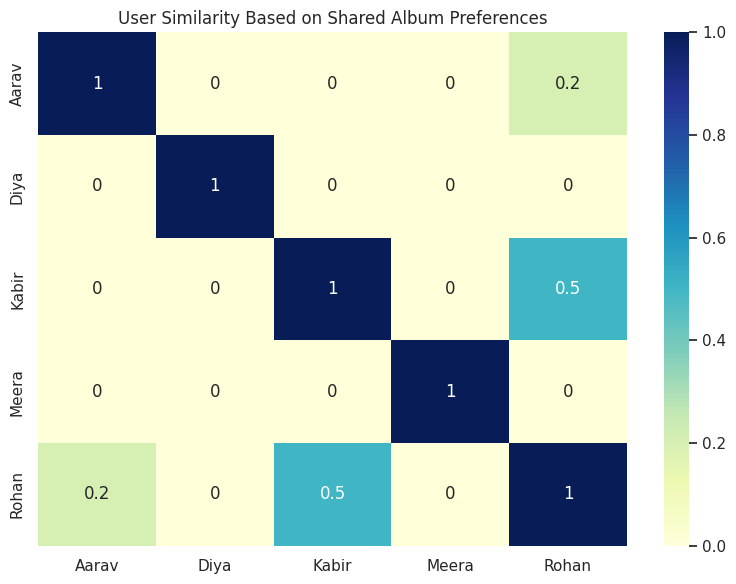

In [28]:
# Sample users for demonstration.
sample_user_preferences = {
    "Aarav": ["Exile On Main Street", "Sticky Fingers", "Let It Bleed"],
    "Diya": ["Blue & Lonesome", "Live At The El Mocambo", "Licked Live In NYC"],
    "Kabir": ["Tattoo You", "Some Girls", "Goats Head Soup"],
    "Meera": ["Aftermath", "Out Of Our Heads", "The Rolling Stones"],
    "Rohan": ["Sticky Fingers", "Tattoo You", "Goats Head Soup"],
}

all_user_albums = sorted({album for albums in sample_user_preferences.values() for album in albums})
user_album_matrix = pd.DataFrame(0, index=sample_user_preferences.keys(), columns=all_user_albums)

for user_name, liked_album_list in sample_user_preferences.items():
    user_album_matrix.loc[user_name, liked_album_list] = 1

display(user_album_matrix)

def jaccard_similarity(items_a, items_b):
    """Measure overlap between two sets of liked albums."""
    set_a = set(items_a)
    set_b = set(items_b)
    union = set_a | set_b
    if not union:
        return 0.0
    return len(set_a & set_b) / len(union)

user_similarity_matrix = pd.DataFrame(index=user_album_matrix.index, columns=user_album_matrix.index, dtype=float)
for user_a in user_album_matrix.index:
    for user_b in user_album_matrix.index:
        user_similarity_matrix.loc[user_a, user_b] = jaccard_similarity(
            sample_user_preferences[user_a],
            sample_user_preferences[user_b],
        )

display(user_similarity_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(user_similarity_matrix.astype(float), annot=True, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("User Similarity Based on Shared Album Preferences")
plt.tight_layout()
plt.show()

## Step 14: Recommend albums using similar users

What we do in this step:
- Find the users most similar to a target user.
- Collect albums those similar users like.
- Recommend albums the target user has not liked yet.

Why this matters:
- This gives us a collaborative filtering style recommendation.
- It uses user associations rather than only audio features.

In [29]:
def get_similar_users(user_name, top_n=2):
    """Return the most similar users for a target user."""
    if user_name not in user_similarity_matrix.index:
        raise ValueError(f"Unknown user: {user_name}")
    similar_users = user_similarity_matrix.loc[user_name].drop(user_name).sort_values(ascending=False)
    return similar_users.head(top_n)

def recommend_from_similar_users(user_name, top_n_users=2, top_n_albums=5):
    """Recommend albums by looking at the preferences of similar users."""
    liked_albums = set(sample_user_preferences[user_name])
    similar_users = get_similar_users(user_name, top_n=top_n_users)

    recommendation_scores = {}
    for similar_user, similarity_score in similar_users.items():
        for album in sample_user_preferences[similar_user]:
            if album not in liked_albums:
                recommendation_scores[album] = recommendation_scores.get(album, 0) + similarity_score

    recommendation_df = pd.DataFrame(
        [{"album_base": album, "association_score": score} for album, score in recommendation_scores.items()]
    )

    if recommendation_df.empty:
        return recommendation_df

    recommendation_df = recommendation_df.merge(
        album_popularity_lookup.reset_index(),
        on="album_base",
        how="left",
    )

    return recommendation_df.sort_values(
        ["association_score", "popular_song_count", "average_popularity"],
        ascending=False,
    ).head(top_n_albums)

# Example: user-based recommendation for a sample user.
print("Users most similar to Aarav:")
display(get_similar_users("Aarav", top_n=3))

print("Albums recommended to Aarav from similar users:")
display(recommend_from_similar_users("Aarav", top_n_users=3, top_n_albums=5))

Users most similar to Aarav:


,Aarav
Rohan,0.2
Diya,0.0
Kabir,0.0


Albums recommended to Aarav from similar users:


,album_base,association_score,average_popularity,song_count,popular_song_count
0,Tattoo You,0.2,24.278481,79,23
1,Goats Head Soup,0.2,26.280702,57,22
4,Licked Live In NYC,0.0,28.608696,23,17
5,Some Girls,0.0,24.685185,54,15
3,Live At The El Mocambo,0.0,27.260870,23,14


## Step 15: Ready-to-use utility examples

Use these examples when you want to quickly test the recommendation utilities.

Example ideas:
- Recommend albums from a few favorite songs.
- Recommend albums from already liked albums.
- Recommend albums for a user cluster preference.
- Recommend albums using similar users.

In [30]:
# 1. Song-based recommendation
display(recommend_albums_for_user(
    liked_songs=["Paint It, Black", "Start Me Up - Remastered 2009"],
    top_n=5,
))

# 2. Album-based recommendation
display(recommend_albums_for_user(
    liked_albums=["Sticky Fingers", "Tattoo You"],
    top_n=5,
))

# 3. Cluster-based recommendation
display(recommend_albums_for_user(
    preferred_clusters=[0],
    top_n=5,
))

# 4. Similar-user recommendation
display(recommend_from_similar_users("Kabir", top_n_users=2, top_n_albums=5))

,similarity_score,popular_song_count,average_popularity,song_count
album_base,,,,
The Rolling Stones,0.978551,12,34.166667,12
Black And Blue,0.976786,9,30.187500,16
Blue & Lonesome,0.974809,12,34.916667,12
Let It Bleed,0.973830,20,34.962963,27
Voodoo Lounge,0.971995,14,34.000000,15


,similarity_score,popular_song_count,average_popularity,song_count
album_base,,,,
Honk,0.999962,18,26.212766,47
Bridges To Babylon,0.999949,13,26.923077,26
Some Girls,0.999933,15,24.685185,54
Exile On Main Street,0.999909,36,23.840000,75
Goats Head Soup,0.999893,22,26.280702,57


,similarity_score,popular_song_count,average_popularity,song_count
album_base,,,,
Exile On Main Street,0.999961,36,23.840000,75
Tattoo You,0.999943,23,24.278481,79
Emotional Rescue,0.999910,11,26.850000,20
Ladies & Gentlemen,0.999890,0,21.437500,16
Get Yer Ya-Ya's Out!,0.999860,3,25.900000,10


,album_base,association_score,average_popularity,song_count,popular_song_count
0,Sticky Fingers,0.5,28.079365,63,23
1,Exile On Main Street,0.0,23.840000,75,36
2,Let It Bleed,0.0,34.962963,27,20


## Final takeaway

This notebook solves the problem statement in a complete flow:
- We inspected and cleaned the data.
- We engineered helpful features such as `release_year`, `duration_min`, and `album_base`.
- We identified album recommendations using the number of popular songs.
- We studied how popularity relates to audio features and how those relationships change over time.
- We used PCA to understand the structure of the feature space.
- We created clusters of similar songs to form song cohorts.
- We added utility methods so a user can get album recommendations from songs, albums, clusters, or similar users.

If you submit this notebook, add your written observations below each output after running the notebook once. That makes the analysis stronger and more personalized.